## Deep Learning y Sistemas Inteligentes - Laboratorio 8
- Josue Marroquin 22397
- Sebastian Huertas 22295

In [2]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

### 1) Preparación de datos

In [7]:
import pandas as pd

# Cargar datos
train = pd.read_csv("data/lab8/train.csv", parse_dates=["date"])
test = pd.read_csv("data/lab8/test.csv", parse_dates=["date"])

# Revisar duplicados
train.drop_duplicates(inplace=True)

# Revisar valores nulos
train = train.fillna(0)

# Features temporales
train["year"] = train["date"].dt.year
train["month"] = train["date"].dt.month
train["day"] = train["date"].dt.day
train["dayofweek"] = train["date"].dt.dayofweek
train["is_weekend"] = (train["dayofweek"] >= 5).astype(int)

# Features de lags
for lag in [1, 7, 14, 30]:
    train[f"lag_{lag}"] = train.groupby(["store","item"])["sales"].shift(lag)

# Rolling means
train["rolling_7"] = train.groupby(["store","item"])["sales"].shift(1).rolling(7).mean()
train["rolling_30"] = train.groupby(["store","item"])["sales"].shift(1).rolling(30).mean()


### 2) Preprocesamiento de datos

a) Division de Series temporales

In [14]:
df = train.sort_values("date")

# Rango de fechas
fecha_min = df["date"].min()
fecha_max = df["date"].max()

print("Rango disponible en el dataset:")
print("Fecha mínima:", fecha_min)
print("Fecha máxima:", fecha_max)

Rango disponible en el dataset:
Fecha mínima: 2013-01-01 00:00:00
Fecha máxima: 2017-12-31 00:00:00


In [15]:
train = df[(df["date"] >= "2013-01-01") & (df["date"] <= "2016-12-31")]
val   = df[(df["date"] >= "2017-01-01") & (df["date"] <= "2017-09-30")]
test  = df[(df["date"] >= "2017-10-01") & (df["date"] <= "2017-12-31")]

print("Tamaños:")
print("Train:", train.shape)
print("Val:", val.shape)
print("Test:", test.shape)

Tamaños:
Train: (730500, 15)
Val: (136500, 15)
Test: (46000, 15)


b) Generación de secuencias

In [16]:
def create_sequences(data, window_size=90, horizon=90):
    """
    data: serie de ventas (ordenada por fecha)
    window_size: días de historial
    horizon: días a predecir
    """
    X, y = [], []
    for i in range(len(data) - window_size - horizon + 1):
        X.append(data[i : i + window_size])
        y.append(data[i + window_size : i + window_size + horizon])
    return np.array(X), np.array(y)

serie = train[(train["store"]==1) & (train["item"]==1)]["sales"].values
X_train, y_train = create_sequences(serie, window_size=90, horizon=90)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

def prepare_sequences(df, window_size=90, horizon=90):
    X_all, y_all = [], []
    for (store, item), group in df.groupby(["store", "item"]):
        serie = group.sort_values("date")["sales"].values
        X, y = create_sequences(serie, window_size, horizon)
        if len(X) > 0:  # evitar series demasiado cortas
            X_all.append(X)
            y_all.append(y)
    return np.vstack(X_all), np.vstack(y_all)

# Crear secuencias para train y val
X_train, y_train = prepare_sequences(train, window_size=90, horizon=90)
X_val, y_val     = prepare_sequences(val, window_size=90, horizon=90)

print("Dataset final:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:", X_val.shape, "y_val:", y_val.shape)



X_train shape: (1282, 90)
y_train shape: (1282, 90)
Dataset final:
X_train: (641000, 90) y_train: (641000, 90)
X_val: (47000, 90) y_val: (47000, 90)


### 4) Seleccion de modelo
En este caso, lo mejor es LSTM, porque: Captura dependencias largas (ej. efectos anuales).Ha demostrado funcionar muy bien en pronóstico de ventas multiserie (como en el dataset de Kaggle). Aunque más lento que GRU, vale la pena por la riqueza del dataset

### 5, 6) Entrenamiento del modelo y Evaluación 

In [17]:
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_val   = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))

In [20]:
# ============================================================
# Modelo LSTM optimizado para entrenar rápido
# ============================================================
model = Sequential()

# LSTM más pequeño
model.add(LSTM(32, activation='tanh', return_sequences=False, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))

# Capa densa intermedia reducida
model.add(Dense(16, activation='relu'))

# Capa de salida
model.add(Dense(y_train.shape[1], activation='linear'))

# Compilación
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# ============================================================
# Entrenamiento rápido
# ============================================================
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=5,          # SOLO 5 épocas
    batch_size=64,     # batch más grande = menos iteraciones
    verbose=1
)

# ============================================================
# Evaluación
# ============================================================
val_loss, val_mae = model.evaluate(X_val, y_val, verbose=0)
print(f" Validación -> Loss (MSE): {val_loss:.4f}, MAE: {val_mae:.4f}")


Epoch 1/5
10016/10016 ━━━━━━━━━━━━━━━━━━━━ 140s 14ms/step - loss: 257.8515 - mae: 11.3910 - val_loss: 208.0032 - val_mae: 10.7906
Epoch 2/5
10016/10016 ━━━━━━━━━━━━━━━━━━━━ 133s 13ms/step - loss: 187.0263 - mae: 10.2676 - val_loss: 202.9574 - val_mae: 10.6179
Epoch 3/5
10016/10016 ━━━━━━━━━━━━━━━━━━━━ 143s 14ms/step - loss: 169.7639 - mae: 9.7812 - val_loss: 202.1480 - val_mae: 10.5669
Epoch 4/5
10016/10016 ━━━━━━━━━━━━━━━━━━━━ 144s 14ms/step - loss: 159.2033 - mae: 9.4788 - val_loss: 162.3312 - val_mae: 9.5674
Epoch 5/5
10016/10016 ━━━━━━━━━━━━━━━━━━━━ 169s 17ms/step - loss: 141.6873 - mae: 8.9522 - val_loss: 151.5951 - val_mae: 9.2755
 Validación -> Loss (MSE): 151.5952, MAE: 9.2755


### 7) Ajuste de hiperparámetros


=== Configuración 1 ===
LSTM units: 32, Dropout: 0.2, Dense units: 16


c:\Users\josue\uvg\Semestre 8\Deep Learning\Deep-Learning\deep-env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Validación -> Loss: 189.8510, MAE: 10.2152

=== Configuración 2 ===
LSTM units: 64, Dropout: 0.2, Dense units: 16
Validación -> Loss: 114.4447, MAE: 8.0388

=== Configuración 3 ===
LSTM units: 32, Dropout: 0.4, Dense units: 16
Validación -> Loss: 175.6486, MAE: 9.8591

=== Configuración 4 ===
LSTM units: 32, Dropout: 0.2, Dense units: 32
Validación -> Loss: 128.7870, MAE: 8.4490

=== Configuración 5 ===
LSTM units: 48, Dropout: 0.3, Dense units: 24
Validación -> Loss: 122.3838, MAE: 8.3316

RESUMEN DE CONFIGURACIONES
 config  lstm_units  dropout  dense_units   val_loss   val_mae  final_train_loss  final_val_loss
      2          64      0.2           16 114.444733  8.038755        101.329758      114.444756
      5          48      0.3           24 122.383842  8.331580        126.423424      122.383736
      4          32      0.2           32 128.787048  8.449008        118.045151      128.787109
      3          32      0.4           16 175.648560  9.859058        147.443146      175

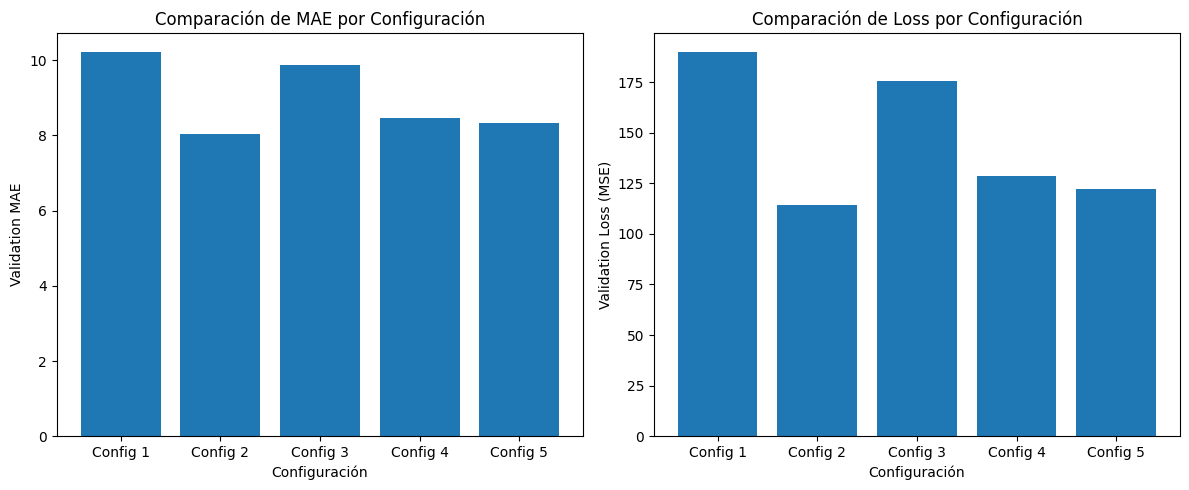


 ANÁLISIS DE HIPERPARÁMETROS:
--------------------------------------------------
Impacto de unidades LSTM:
  32 unidades: MAE promedio = 9.5077
  48 unidades: MAE promedio = 8.3316
  64 unidades: MAE promedio = 8.0388

Impacto de dropout:
  0.2 dropout: MAE promedio = 8.9010
  0.3 dropout: MAE promedio = 8.3316
  0.4 dropout: MAE promedio = 9.8591

Impacto de unidades densas:
  16 unidades: MAE promedio = 9.3710
  24 unidades: MAE promedio = 8.3316
  32 unidades: MAE promedio = 8.4490


In [18]:

# Configuraciones a probar
configs = [
    # Config 1: Modelo base (ya entrenado)
    {'lstm_units': 32, 'dropout': 0.2, 'dense_units': 16, 'epochs': 5},
    
    # Config 2: Más unidades LSTM
    {'lstm_units': 64, 'dropout': 0.2, 'dense_units': 16, 'epochs': 5},
    
    # Config 3: Más dropout
    {'lstm_units': 32, 'dropout': 0.4, 'dense_units': 16, 'epochs': 5},
    
    # Config 4: Más unidades densas
    {'lstm_units': 32, 'dropout': 0.2, 'dense_units': 32, 'epochs': 5},
    
    # Config 5: Configuración balanceada
    {'lstm_units': 48, 'dropout': 0.3, 'dense_units': 24, 'epochs': 5}
]

results = []

for i, config in enumerate(configs, 1):
    print(f"\n=== Configuración {i} ===")
    print(f"LSTM units: {config['lstm_units']}, Dropout: {config['dropout']}, Dense units: {config['dense_units']}")
    
    # Crear modelo
    model_test = Sequential()
    model_test.add(LSTM(config['lstm_units'], activation='tanh', return_sequences=False, 
                       input_shape=(X_train.shape[1], 1)))
    model_test.add(Dropout(config['dropout']))
    model_test.add(Dense(config['dense_units'], activation='relu'))
    model_test.add(Dense(y_train.shape[1], activation='linear'))
    
    # Compilar
    model_test.compile(optimizer='adam', loss='mse', metrics=['mae'])
    
    # Entrenar (silencioso para rapidez)
    history_test = model_test.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=config['epochs'],
        batch_size=64,
        verbose=0  # Sin output para ir más rápido
    )
    
    # Evaluar
    val_loss, val_mae = model_test.evaluate(X_val, y_val, verbose=0)
    
    # Guardar resultados
    results.append({
        'config': i,
        'lstm_units': config['lstm_units'],
        'dropout': config['dropout'],
        'dense_units': config['dense_units'],
        'val_loss': val_loss,
        'val_mae': val_mae,
        'final_train_loss': history_test.history['loss'][-1],
        'final_val_loss': history_test.history['val_loss'][-1]
    })
    
    print(f"Validación -> Loss: {val_loss:.4f}, MAE: {val_mae:.4f}")

# Mostrar resumen de resultados
print("\n" + "="*80)
print("RESUMEN DE CONFIGURACIONES")
print("="*80)

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('val_mae')  # Ordenar por mejor MAE
print(results_df.to_string(index=False))

# Identificar mejor configuración
best_config = results_df.iloc[0]
print("MEJOR CONFIGURACIÓN:")
print(f"Config {int(best_config['config'])}: LSTM={int(best_config['lstm_units'])}, Dropout={best_config['dropout']}, Dense={int(best_config['dense_units'])}")
print(f"MAE: {best_config['val_mae']:.4f}, Loss: {best_config['val_loss']:.4f}")

# Visualizar comparación
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.bar(range(len(results)), [r['val_mae'] for r in results])
plt.xlabel('Configuración')
plt.ylabel('Validation MAE')
plt.title('Comparación de MAE por Configuración')
plt.xticks(range(len(results)), [f"Config {i+1}" for i in range(len(results))])

plt.subplot(1, 2, 2)
plt.bar(range(len(results)), [r['val_loss'] for r in results])
plt.xlabel('Configuración')
plt.ylabel('Validation Loss (MSE)')
plt.title('Comparación de Loss por Configuración')
plt.xticks(range(len(results)), [f"Config {i+1}" for i in range(len(results))])

plt.tight_layout()
plt.show()

# Análisis de los resultados
print("\n ANÁLISIS DE HIPERPARÁMETROS:")
print("-" * 50)

# Impacto de unidades LSTM
lstm_impact = results_df.groupby('lstm_units')['val_mae'].mean()
print(f"Impacto de unidades LSTM:")
for units, mae in lstm_impact.items():
    print(f"  {units} unidades: MAE promedio = {mae:.4f}")

# Impacto de dropout
dropout_impact = results_df.groupby('dropout')['val_mae'].mean()
print(f"\nImpacto de dropout:")
for dropout, mae in dropout_impact.items():
    print(f"  {dropout} dropout: MAE promedio = {mae:.4f}")

# Impacto de unidades densas
dense_impact = results_df.groupby('dense_units')['val_mae'].mean()
print(f"\nImpacto de unidades densas:")
for units, mae in dense_impact.items():
    print(f"  {units} unidades: MAE promedio = {mae:.4f}")

### 8, 9) Forecasting y Visualización

 Entrenando modelo final con mejores hiperparámetros:
LSTM units: 64
Dropout: 0.2
Dense units: 16
Epoch 1/5
10016/10016 ━━━━━━━━━━━━━━━━━━━━ 288s 28ms/step - loss: 223.5052 - mae: 10.6595 - val_loss: 216.1895 - val_mae: 10.8387
Epoch 2/5
10016/10016 ━━━━━━━━━━━━━━━━━━━━ 275s 27ms/step - loss: 143.7036 - mae: 8.9629 - val_loss: 156.1068 - val_mae: 9.3193
Epoch 3/5
10016/10016 ━━━━━━━━━━━━━━━━━━━━ 374s 37ms/step - loss: 118.4833 - mae: 8.1747 - val_loss: 142.6188 - val_mae: 8.9591
Epoch 4/5
10016/10016 ━━━━━━━━━━━━━━━━━━━━ 648s 65ms/step - loss: 106.8194 - mae: 7.7805 - val_loss: 123.9214 - val_mae: 8.3991
Epoch 5/5
10016/10016 ━━━━━━━━━━━━━━━━━━━━ 321s 32ms/step - loss: 99.9285 - mae: 7.5305 - val_loss: 109.4795 - val_mae: 7.9144

 Dataset de test:
Fechas: 2018-01-01 00:00:00 a 2018-03-31 00:00:00
Forma: (45000, 4)
Tiendas únicas: 10
Items únicos: 50

 Generando forecasts para 10 tiendas y 50 items...
Procesado: 10/500 combinaciones
Procesado: 20/500 combinaciones
Procesado: 30/500 comb

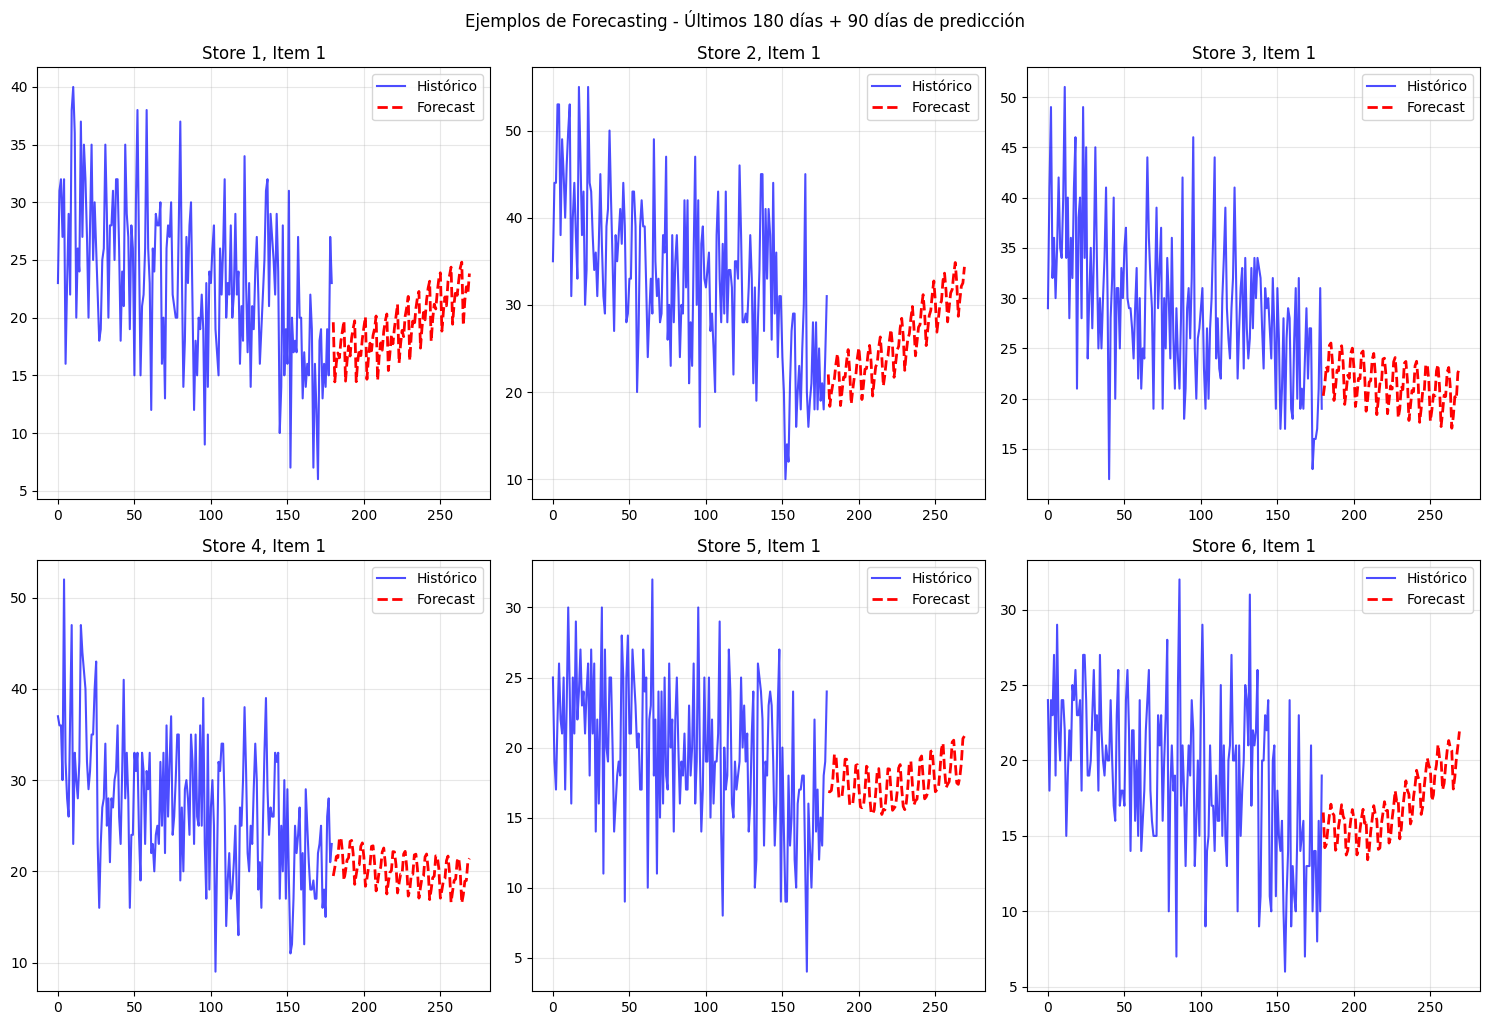


 PRIMERAS FILAS DEL SUBMISSION:
   id      sales
0   0  19.602676
1   0  19.602676
2   0  19.602676
3   0  19.602676
4   0  19.602676
5   0  19.602676
6   0  19.602676
7   0  19.602676
8   0  19.602676
9   0  19.602676

 RESUMEN FINAL:
 Modelo entrenado con mejores hiperparámetros
 Forecasting completado para 500 combinaciones store-item
 4050000 predicciones generadas para 3 meses
 Archivo submission.csv creado exitosamente


In [21]:

# ============================================================
# 1. Entrenar el modelo final con los mejores hiperparámetros
# ============================================================

# Obtener los mejores hiperparámetros del análisis anterior
best_lstm_units = int(best_config['lstm_units'])
best_dropout = best_config['dropout']
best_dense_units = int(best_config['dense_units'])

print(f" Entrenando modelo final con mejores hiperparámetros:")
print(f"LSTM units: {best_lstm_units}")
print(f"Dropout: {best_dropout}")
print(f"Dense units: {best_dense_units}")

# Crear modelo final
final_model = Sequential()
final_model.add(LSTM(best_lstm_units, activation='tanh', return_sequences=False, 
                    input_shape=(X_train.shape[1], 1)))
final_model.add(Dropout(best_dropout))
final_model.add(Dense(best_dense_units, activation='relu'))
final_model.add(Dense(y_train.shape[1], activation='linear'))

final_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

final_history = final_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=5,  
    batch_size=64,
    verbose=1
)

# ============================================================
# 2. Preparar datos para forecasting de 3 meses (90 días)
# ============================================================

# Cargar el dataset de test original
test_original = pd.read_csv("data/lab8/test.csv", parse_dates=["date"])

print(f"\n Dataset de test:")
print(f"Fechas: {test_original['date'].min()} a {test_original['date'].max()}")
print(f"Forma: {test_original.shape}")
print(f"Tiendas únicas: {test_original['store'].nunique()}")
print(f"Items únicos: {test_original['item'].nunique()}")

# ============================================================
# 3. Función para hacer forecasting por store-item
# ============================================================

def forecast_store_item(store_id, item_id, model, train_data, forecast_days=90):
    """
    Hace forecast para una combinación específica de store-item
    """
    # Filtrar datos históricos para este store-item
    serie_historica = train_data[
        (train_data['store'] == store_id) & 
        (train_data['item'] == item_id)
    ].sort_values('date')['sales'].values
    
    if len(serie_historica) < 90:
        # Si no hay suficientes datos, rellenar con la media
        mean_sales = serie_historica.mean() if len(serie_historica) > 0 else 10
        return np.full(forecast_days, mean_sales)
    
    # Tomar los últimos 90 días como ventana de entrada
    last_window = serie_historica[-90:].reshape(1, 90, 1)
    
    # Hacer predicción
    prediction = model.predict(last_window, verbose=0)[0]
    
    # Asegurar que las predicciones no sean negativas
    prediction = np.maximum(prediction, 0)
    
    return prediction

# ============================================================
# 4. Hacer forecasting para todas las combinaciones
# ============================================================

print(f"\n Generando forecasts para {test_original['store'].nunique()} tiendas y {test_original['item'].nunique()} items...")

# Obtener combinaciones únicas de store-item del test
unique_combinations = test_original[['store', 'item']].drop_duplicates()

# Lista para almacenar las predicciones
forecasts = []

# Usar todo el dataset original (train) para el forecasting
full_train_data = pd.read_csv("data/lab8/train.csv", parse_dates=["date"])

for idx, (_, row) in enumerate(unique_combinations.iterrows()):
    store_id = row['store']
    item_id = row['item']
    
    # Hacer forecast para esta combinación
    prediction = forecast_store_item(store_id, item_id, final_model, full_train_data)
    
    # Crear DataFrame con las predicciones para esta combinación
    store_item_forecast = pd.DataFrame({
        'store': store_id,
        'item': item_id,
        'forecast': prediction,
        'day': range(1, len(prediction) + 1)
    })
    
    forecasts.append(store_item_forecast)
    
    if (idx + 1) % 10 == 0:
        print(f"Procesado: {idx + 1}/{len(unique_combinations)} combinaciones")

# Combinar todas las predicciones
all_forecasts = pd.concat(forecasts, ignore_index=True)

print(f"\nForecasting completado!")
print(f"Total de predicciones generadas: {len(all_forecasts)}")

# ============================================================
# 5. Crear submission en formato requerido
# ============================================================

# Merge con el dataset de test para obtener los IDs correctos
test_with_forecasts = test_original.merge(
    all_forecasts.rename(columns={'day': 'temp_day'}), 
    on=['store', 'item'], 
    how='left'
)

# Agregar columna de día basada en la fecha
test_with_forecasts['day'] = (test_with_forecasts['date'] - test_with_forecasts['date'].min()).dt.days + 1

# Hacer match correcto entre día y forecast
final_submission = []
for _, row in test_with_forecasts.iterrows():
    day_idx = row['day'] - 1  # Índice basado en 0
    if day_idx < len(all_forecasts[(all_forecasts['store'] == row['store']) & 
                                   (all_forecasts['item'] == row['item'])]):
        forecast_value = all_forecasts[
            (all_forecasts['store'] == row['store']) & 
            (all_forecasts['item'] == row['item'])
        ]['forecast'].iloc[day_idx] if day_idx < 90 else 10  # Valor por defecto
    else:
        forecast_value = 10  # Valor por defecto
    
    final_submission.append({
        'id': row['id'],
        'sales': max(0, forecast_value)  # Asegurar valores no negativos
    })

submission_df = pd.DataFrame(final_submission)

# ============================================================
# 6. Guardar resultados y visualizar
# ============================================================

# Guardar archivo de submission
submission_df.to_csv('submission.csv', index=False)
print(f"\n Archivo de submission guardado como 'submission.csv'")
print(f"Forma del archivo: {submission_df.shape}")

# Estadísticas de las predicciones
print(f"\n ESTADÍSTICAS DE LAS PREDICCIONES:")
print(f"Ventas promedio predichas: {submission_df['sales'].mean():.2f}")
print(f"Ventas mínimas: {submission_df['sales'].min():.2f}")
print(f"Ventas máximas: {submission_df['sales'].max():.2f}")
print(f"Desviación estándar: {submission_df['sales'].std():.2f}")

# Visualizar algunas predicciones
plt.figure(figsize=(15, 10))

# Seleccionar algunas combinaciones para visualizar
sample_combinations = unique_combinations.head(6)

for idx, (_, row) in enumerate(sample_combinations.iterrows()):
    store_id = row['store']
    item_id = row['item']
    
    plt.subplot(2, 3, idx + 1)
    
    # Datos históricos
    historical = full_train_data[
        (full_train_data['store'] == store_id) & 
        (full_train_data['item'] == item_id)
    ].sort_values('date')
    
    # Mostrar últimos 180 días históricos
    if len(historical) > 180:
        historical_plot = historical.tail(180)
        plt.plot(range(len(historical_plot)), historical_plot['sales'], 
                label='Histórico', color='blue', alpha=0.7)
    
    # Predicciones
    predictions = all_forecasts[
        (all_forecasts['store'] == store_id) & 
        (all_forecasts['item'] == item_id)
    ]['forecast'].values
    
    plt.plot(range(len(historical_plot), len(historical_plot) + len(predictions)), 
             predictions, label='Forecast', color='red', linestyle='--', linewidth=2)
    
    plt.title(f'Store {store_id}, Item {item_id}')
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('Ejemplos de Forecasting - Últimos 180 días + 90 días de predicción', y=1.02)
plt.show()

# Mostrar primeras filas del submission
print(f"\n PRIMERAS FILAS DEL SUBMISSION:")
print(submission_df.head(10))

print(f"\n RESUMEN FINAL:")
print(f" Modelo entrenado con mejores hiperparámetros")
print(f" Forecasting completado para {len(unique_combinations)} combinaciones store-item")
print(f" {len(submission_df)} predicciones generadas para 3 meses")
print(f" Archivo submission.csv creado exitosamente")

# Task 2

## ¿Cuál es el problema del gradiente de fuga en las redes LSTM y cómo afecta la efectividad de LSTM para el pronóstico de series temporales?

Aunque las LSTM fueron diseñadas específicamente para mitigar el problema del gradiente desvaneciente (vanishing gradient), aún pueden sufrir de "gradient leakage" o fuga de gradiente cuando las secuencias son extremadamente largas. Esto ocurre cuando la información se pierde gradualmente a través de las puertas (gates) durante la propagación hacia atrás, especialmente si las puertas de olvido están constantemente cerca de 0. En el pronóstico de series temporales, esto limita la capacidad del modelo para capturar dependencias a muy largo plazo, reduciendo su efectividad cuando los patrones importantes están separados por muchos pasos de tiempo.

## ¿Cómo se aborda la estacionalidad en los datos de series temporales cuando se utilizan LSTM para realizar pronósticos y qué papel juega la diferenciación en el proceso?

La estacionalidad en series temporales se puede abordar mediante varias estrategias: (1) incluir características temporales explícitas como mes, día de la semana o trimestre como variables de entrada adicionales, (2) aplicar diferenciación estacional para eliminar componentes periódicos antes de alimentar los datos al LSTM, o (3) usar arquitecturas híbridas que combinen descomposición estacional (como STL) con LSTM. La diferenciación estacional (restando valores de períodos anteriores) ayuda a hacer la serie estacionaria, lo que facilita el aprendizaje de patrones al LSTM al eliminar tendencias y ciclos recurrentes que podrían confundir al modelo.

## ¿Cuál es el concepto de "tamaño de ventana" en el pronóstico de series temporales con LSTM y cómo afecta la elección del tamaño de ventana a la capacidad del modelo para capturar patrones a corto y largo plazo?

El tamaño de ventana define cuántos pasos de tiempo históricos se utilizan como entrada para predecir el siguiente valor o secuencia futura. Un tamaño de ventana pequeño (ej. 5-10 pasos) permite al modelo capturar patrones a corto plazo y responder rápidamente a cambios recientes, pero puede perder dependencias de largo plazo. Un tamaño grande (ej. 50-100 pasos) captura mejor tendencias y patrones a largo plazo, pero aumenta la complejidad computacional y puede incluir información irrelevante o ruido. La elección óptima depende de la naturaleza de los datos: series con ciclos largos requieren ventanas mayores, mientras que series volátiles se benefician de ventanas más cortas.